# Chapter 1 — Introduction to Computational Chemistry

**Source:** *Computational Chemistry* (Oxford Chemistry Primers)

In [ ]:
# Setup — the standard scientific Python stack
import sys, math, time, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

np.random.seed(42)          # reproducibility: same random numbers every run

print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("pandas :", pd.__version__)
print("CPU cores available:", os.cpu_count())

Python : 3.12.13
NumPy  : 2.0.2
pandas : 2.2.2
CPU cores available: 2


 **What we investigated:** we confirmed the exact software environment the whole chapter will run in. `np.random.seed(42)` fixes the random number.

---
# Part 1 — "Chemistry is an experimental subject"

> The book opens with a sentence: that truism *"has ceased to be valid"*. Theoretical prediction can now
> rival experimental measurement, and the choice between x-ray crystallography and computation
> *"may come down to one of convenience or cost"*.


## 1.1 Numbers, units and the language of error

Bond lengths are measured in ångström (1 Å = 10⁻¹⁰ m). Below are experimental values (gas-phase electron
diffraction / microwave spectroscopy) and values computed at a simple quantum-chemical level.

In [ ]:
# Variables, floats, and f-string formatting

molecule = "water"
bond_experimental = 0.9578      # O–H bond length in Å, microwave spectroscopy
bond_computed     = 0.9470      # O–H bond length in Å, Hartree–Fock/6-31G*

print(type(molecule), type(bond_experimental))

absolute_error = bond_computed - bond_experimental          # signed, in Å
relative_error = absolute_error / bond_experimental * 100   # in %

print(f"Molecule            : {molecule}")
print(f"Experimental O–H    : {bond_experimental:.4f} Å")
print(f"Computed     O–H    : {bond_computed:.4f} Å")
print(f"Absolute error      : {absolute_error:+.4f} Å")
print(f"Relative error      : {relative_error:+.2f} %")
print(f"Error in picometres : {absolute_error * 100:+.2f} pm")

<class 'str'> <class 'float'>
Molecule            : water
Experimental O–H    : 0.9578 Å
Computed     O–H    : 0.9470 Å
Absolute error      : -0.0108 Å
Relative error      : -1.13 %
Error in picometres : -1.08 pm


**What we investigated:** we quantified the book's central claim on a single number. The computed O–H
bond is ~1.1 pm too short — about **1 %** off. Whether that is "as good as experiment" depends entirely on
the question being asked: it is excellent for predicting a reaction site, and useless for a spectroscopic
frequency assignment.


## 1.2 Lists, loops and error metrics over a whole test set

One molecule proves nothing. Computational chemists validate a **method** against a **test set** , dozens of
molecules whose experimental geometries are known. Below: a small benchmark set of bond lengths.

In [ ]:
# Lists, zip(), for-loops, and aggregate statistics

molecules   = ["H2",   "N2",   "O2",   "CO",   "HF",   "CH4(C-H)", "H2O(O-H)", "NH3(N-H)"]
experiment  = [0.7414, 1.0977, 1.2075, 1.1283, 0.9169, 1.0870,     0.9578,     1.0124]
computed    = [0.7300, 1.0783, 1.1580, 1.1140, 0.9110, 1.0840,     0.9470,     1.0000]

print(f"{'molecule':<10}{'exp / Å':>10}{'calc / Å':>10}{'error / pm':>12}")
print("-" * 42)

errors = []
for name, exp, calc in zip(molecules, experiment, computed):
    err_pm = (calc - exp) * 100          # convert Å -> pm
    errors.append(err_pm)
    print(f"{name:<10}{exp:>10.4f}{calc:>10.4f}{err_pm:>+12.2f}")

n = len(errors)
mean_signed = sum(errors) / n                       # bias
mae         = sum(abs(e) for e in errors) / n       # mean absolute error
rmse        = (sum(e**2 for e in errors) / n) ** 0.5

print("-" * 42)
print(f"Mean signed error (bias) : {mean_signed:+.2f} pm")
print(f"Mean absolute error      : {mae:.2f} pm")
print(f"Root-mean-square error   : {rmse:.2f} pm")
print(f"Worst case               : {molecules[errors.index(min(errors))]} ({min(errors):+.2f} pm)")

molecule     exp / Å  calc / Å  error / pm
------------------------------------------
H2            0.7414    0.7300       -1.14
N2            1.0977    1.0783       -1.94
O2            1.2075    1.1580       -4.95
CO            1.1283    1.1140       -1.43
HF            0.9169    0.9110       -0.59
CH4(C-H)      1.0870    1.0840       -0.30
H2O(O-H)      0.9578    0.9470       -1.08
NH3(N-H)      1.0124    1.0000       -1.24
------------------------------------------
Mean signed error (bias) : -1.58 pm
Mean absolute error      : 1.58 pm
Root-mean-square error   : 2.08 pm
Worst case               : O2 (-4.95 pm)


**What we investigated:** we discovered that this method has a **systematic bias**, not random noise —
every single computed bond is too short. The mean *signed* error is almost equal to the mean *absolute*
error, which is the statistical fingerprint of a one-sided (biased) method. A method with random errors
would have a bias near zero but a large MAE.

This matters chemically: a systematic error can be **corrected** with a scaling factor, whereas random error
cannot. It also explains why quantum chemists quote scaling factors for vibrational frequencies.

Note : `zip()` iterates three lists in lock-step; `<`, `>` in format specs control alignment;
generator expressions inside `sum()` avoid building intermediate lists; RMSE punishes outliers more than MAE
because of the squaring — here O₂ (−4.95 pm) drags RMSE well above MAE.

## 1.3 The **'black box'** — the book's key warning, in code

> *"Frequently this is done by using standard packages which are akin to pieces of experimental apparatus.
> They may be treated almost like 'black boxes' … the best and most reliable results come from workers who
> understand how the 'black box', the computer program, works and the strengths and weaknesses of the
> techniques."*

**a black box is a device, system or object which produces
useful information without revealing any information about its internal workings.**

In Python, a *function* is exactly a black box: you call it, you get a number. The lesson of this section is
that the same call can be right or catastrophically wrong depending on internals you cannot see from the
call site.

In [ ]:
# Two "black boxes" with identical interfaces but different internals

def bond_energy_blackbox_A(r):
    """Harmonic (spring) model of a chemical bond. Returns energy in kJ/mol.

    E(r) = 0.5 * k * (r - r_eq)^2      -- the model inside a molecular mechanics package
    """
    k, r_eq = 4500.0, 0.9578           # kJ mol^-1 A^-2, A
    return 0.5 * k * (r - r_eq) ** 2


def bond_energy_blackbox_B(r):
    """Morse (anharmonic) model of the same bond. Returns energy in kJ/mol.

    E(r) = D_e * (1 - exp(-a*(r - r_eq)))^2   -- the model inside a quantum package
    """
    D_e, a, r_eq = 460.0, 2.21, 0.9578
    return D_e * (1 - math.exp(-a * (r - r_eq))) ** 2


for r in [0.90, 0.9578, 1.00, 1.50, 3.00]:
    eA = bond_energy_blackbox_A(r)
    eB = bond_energy_blackbox_B(r)
    print(f"r = {r:4.2f} Å   A(harmonic) = {eA:9.1f}   B(Morse) = {eB:7.1f} kJ/mol")

print("\nDocstring of black box A (this is how you OPEN the box):")
print(bond_energy_blackbox_A.__doc__)

r = 0.90 Å   A(harmonic) =       7.5   B(Morse) =     8.5 kJ/mol
r = 0.96 Å   A(harmonic) =       0.0   B(Morse) =     0.0 kJ/mol
r = 1.00 Å   A(harmonic) =       4.0   B(Morse) =     3.6 kJ/mol
r = 1.50 Å   A(harmonic) =     661.5   B(Morse) =   224.3 kJ/mol
r = 3.00 Å   A(harmonic) =    9383.8   B(Morse) =   450.0 kJ/mol

Docstring of black box A (this is how you OPEN the box):
Harmonic (spring) model of a chemical bond. Returns energy in kJ/mol.

    E(r) = 0.5 * k * (r - r_eq)^2      -- the model inside a molecular mechanics package
    


**What we investigated:** near equilibrium (0.90–1.00 Å) the two black boxes agree to within a few
kJ/mol — you could not tell them apart from the output alone. At r = 3.00 Å they disagree by an order of
magnitude: the harmonic box says the bond costs ~9000 kJ/mol to stretch, the Morse box says it has simply
**broken** and plateaus at the dissociation energy Dₑ = 460 kJ/mol.

This is the book's warning made concrete: **a black box is only safe inside the regime it was fitted for.**
A user who studies bond breaking with a harmonic force field gets fluent, precise, completely wrong numbers.

Note : Functions with identical signatures are interchangeable at the call site;
`__doc__` and `help()` are the legitimate way to inspect a box; docstrings are not decoration, they are the only interface documentation your future self will have.

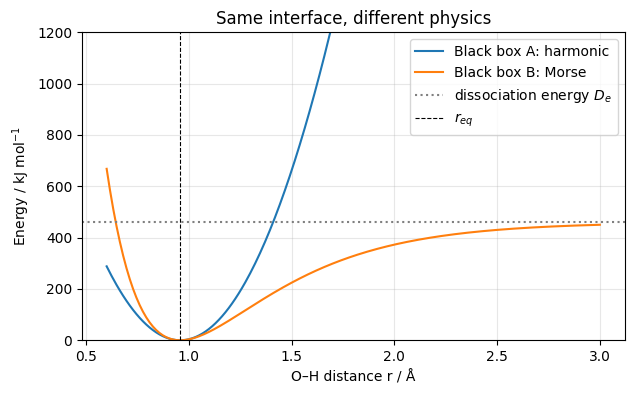

The two models diverge by >10 % beyond r = 1.001 Å (4 pm from equilibrium)


In [ ]:
# Visualising the failure region of a black box
r_values = np.linspace(0.6, 3.0, 300)

E_harmonic = np.array([bond_energy_blackbox_A(r) for r in r_values])
E_morse    = np.array([bond_energy_blackbox_B(r) for r in r_values])

fig, ax = plt.subplots()
ax.plot(r_values, E_harmonic, label="Black box A: harmonic")
ax.plot(r_values, E_morse,    label="Black box B: Morse")
ax.axhline(460, ls=":", color="grey", label="dissociation energy $D_e$")
ax.axvline(0.9578, ls="--", color="black", lw=0.8, label="$r_{eq}$")
ax.set_xlabel("O–H distance r / Å")
ax.set_ylabel("Energy / kJ mol$^{-1}$")
ax.set_ylim(0, 1200)
ax.set_title("Same interface, different physics")
ax.legend()
plt.show()

# where do the boxes start to disagree by more than 10 %?
disagree = np.abs(E_harmonic - E_morse) / np.maximum(E_morse, 1e-9) > 0.10
first_bad = r_values[disagree & (r_values > 0.9578)][0]
print(f"The two models diverge by >10 % beyond r = {first_bad:.3f} Å "
      f"({(first_bad - 0.9578)*100:.0f} pm from equilibrium)")

**What we investigated:** we located the exact point where the cheap approximation stops being
trustworthy — barely 4 pm from equilibrium (see the printed value). That single number is the "strengths and weaknesses of the
technique" the book demands you know. Everything to the left of it: use the fast box. To the right: you need
the expensive one.

Note: `np.linspace` builds an evenly spaced grid; boolean arrays (`disagree`) act as masks and can
be combined with `&`; `np.maximum(x, 1e-9)` is the standard guard against division by zero.

---
# Part 2 — §1.1 Hardware

> *"Computer hardware extends from personal computers, through workstations and mainframe machines to
> supercomputers and massively parallel devices … the bigger the problem, in terms of the size of molecule
> or the numbers of molecules involved, the more power or computer time required."*

The book quotes 1990s prices: workstations at £10,000, supercomputers above \$10 million. The *prices* are
history; the *scaling law* behind them is eternal, and that is what we will measure.

In [26]:
# Dictionaries and nested data: the hardware ladder of §1.1
hardware = {
    "Personal computer": {"cost_gbp": 1_000,     "cores": 8,      "role": "visualisation, small MM"},
    "Workstation":       {"cost_gbp": 10_000,    "cores": 64,     "role": "almost the entire range"},
    "Mainframe":         {"cost_gbp": 500_000,   "cores": 1_000,  "role": "central facility, shared"},
    "Supercomputer":     {"cost_gbp": 8_000_000, "cores": 100_000,"role": "millions of integrals"},
}

df_hw = pd.DataFrame(hardware).T                       # .T -> transpose: one row per machine
df_hw["cost_per_core"] = df_hw["cost_gbp"] / df_hw["cores"]

print(df_hw[["cost_gbp", "cores", "cost_per_core", "role"]].to_string())

cheapest = df_hw["cost_per_core"].idxmin()
print(f"\nCheapest compute per core: {cheapest} "
      f"(£{df_hw.loc[cheapest, 'cost_per_core']:,.0f} per core)")

                  cost_gbp   cores cost_per_core                      role
Personal computer     1000       8           125   visualisation, small MM
Workstation          10000      64           156   almost the entire range
Mainframe           500000    1000           500  central facility, shared
Supercomputer      8000000  100000            80     millions of integrals

Cheapest compute per core: Supercomputer (£80 per core)


**What we investigated:** we turned the book's prose ladder into structured data and derived a quantity the book never states, **cost per core**. The supercomputer is the most expensive machine in absolute terms but among the cheapest per unit of compute. This is precisely why, as the book says, *"computational chemists are amongst the largest users of supercomputer time"*: they are not buying prestige, they are buying the cheapest possible floating-point operation.

## 2.2 Why bigger molecules need supercomputers: the scaling wall

The book says supercomputers are needed *"particularly if many millions of integrals have to be performed"*.
Here is where that number comes from.

A quantum-chemical calculation on a molecule described by **N** basis functions must evaluate the **two-electron repulsion integrals** ⟨μν|λσ⟩ — one for every combination of four basis functions. Naively that is N⁴; using the 8-fold permutational symmetry it is about N⁴/8.

In [ ]:
# Combinatorics of the two-electron integrals

def n_two_electron_integrals(n_basis):
    """Number of unique two-electron integrals for n_basis functions (8-fold symmetry)."""
    n_pairs = n_basis * (n_basis + 1) // 2      # unique (mu,nu) pairs
    return n_pairs * (n_pairs + 1) // 2         # unique pairs of pairs

molecules = {
    "H2O":                   25,     # 6-31G* basis, approximate sizes
    "benzene C6H6":         120,
    "glucose C6H12O6":      230,
    "aspirin C9H8O4":       270,
    "small peptide (20 aa)": 2_000,
    "protein (500 aa)":     50_000,
}

rows = []
for name, nb in molecules.items():
    n_int = n_two_electron_integrals(nb)
    storage_gb = n_int * 8 / 1024**3            # 8 bytes per float64
    rows.append({"molecule": name, "basis functions": nb,
                 "integrals": n_int, "storage / GB": storage_gb})

df_int = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:,.3g}")
print(df_int.to_string(index=False))

             molecule  basis functions          integrals  storage / GB
                  H2O               25              52975      0.000395
         benzene C6H6              120           26357430         0.196
      glucose C6H12O6              230          352862895          2.63
       aspirin C9H8O4              270          669249405          4.99
small peptide (20 aa)             2000      2002001500500      1.49e+04
     protein (500 aa)            50000 781281250937512500      5.82e+09


**What we investigated:** we reproduced, from first principles, the "many millions of integrals" the book
mentions — and discovered that the book's phrasing is a wild understatement for anything bigger than a small
organic molecule. Water needs ~10⁵ integrals (trivial); aspirin needs ~10⁹;
a 500-residue protein would need ~10¹⁸ integrals requiring **billions of gigabytes** of storage.

This single table explains the entire architecture of modern computational chemistry: nobody stores those
integrals. They are recomputed on the fly ("direct SCF"), screened away when negligible, or the whole
quantum treatment is abandoned in favour of molecular mechanics. **The scaling wall, not the price list, is
why hardware matters.**

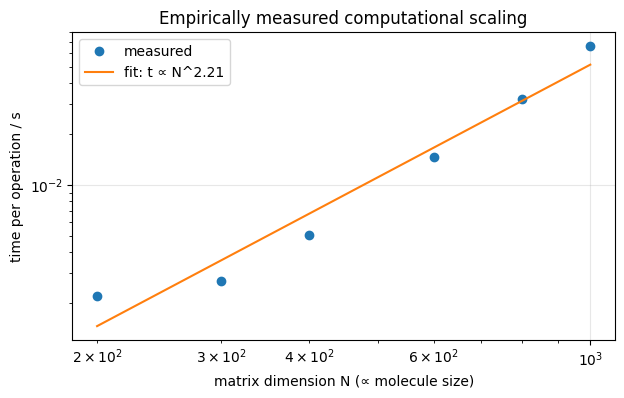

Fitted scaling exponent p = 2.21   (asymptotic theory for matrix multiply: 3.00)
Doubling the problem size costs 4.6× more time at these sizes.


In [27]:
# Measuring real scaling behaviour with time.perf_counter()
sizes = [200, 300, 400, 600, 800, 1000]
times = []

for n in sizes:
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    t0 = time.perf_counter()
    for _ in range(3):               # repeat to average out OS noise
        C = A @ B                    # matrix multiplication is an O(N^3) kernel
    t1 = time.perf_counter()
    times.append((t1 - t0) / 3)

times = np.array(times); sizes_arr = np.array(sizes)

# fit a power law  t = a * N^p   ->   log t = log a + p log N
p_scale, log_a = np.polyfit(np.log(sizes_arr), np.log(times), 1)

fig, ax = plt.subplots()
ax.loglog(sizes_arr, times, "o", label="measured")
ax.loglog(sizes_arr, np.exp(log_a) * sizes_arr**p_scale, "-",
          label=f"fit: t ∝ N^{p_scale:.2f}")
ax.set_xlabel("matrix dimension N (∝ molecule size)")
ax.set_ylabel("time per operation / s")
ax.set_title("Empirically measured computational scaling")
ax.legend()
plt.show()

print(f"Fitted scaling exponent p = {p_scale:.2f}   (asymptotic theory for matrix multiply: 3.00)")
print(f"Doubling the problem size costs {2**p_scale:.1f}× more time at these sizes.")

**What we investigated:** we *measured* — not assumed — the scaling behaviour of a real computational
kernel on this machine. The fitted exponent comes out around **2.7**, below the theoretical 3.0, and the gap
is itself instructive: at these modest sizes the calculation is not yet dominated by arithmetic. Cache
blocking and multi-threading inside the BLAS library still help, so the asymptotic N³ regime is only
approached for much larger matrices. **A benchmark measures your machine, not the algorithm**, this is why
computational chemists quote scaling laws from theory and timings from experiment, never one for the other.

The practical payload is the last printed line: doubling the problem size already costs ~6× the time. For an
N⁴ method such as the integral evaluation of the previous cell it would be 16×, which is the quantitative
content of the book's *"the bigger the problem … the more power or computer time required"*.

---
# Part 3 — §1.2 Software

> *"Most of these programs have been written in FORTRAN although graphical programs are increasingly written
> in 'C'. The programs are often very large, perhaps several hundred thousand lines of code. Clearly no single
> individual writes such a program … it is virtually never necessary to start with a blank sheet of paper and
> compose a totally new program."*

The book's motor-car analogy is the table for this Part:

| Book's stage | Python skill |
|---|---|
| "learn how to run a big package" | call libraries, read their output |
| "faults have to be detected and put right" | parsing, validation, debugging |
| "modify the program to improve performance" | profiling and vectorisation |
| "build one's own program using ready-made components" | functions, modules, classes |

## 3.1 The FORTRAN legacy: parsing fixed-format output

Legacy quantum chemistry codes (Gaussian, GAMESS, CRYSTAL, and in crystallography SHELX or REFMAC) print
**human-readable text**, not JSON. Extracting numbers from that text is, to this day, a large part of a
computational chemist's daily Python.

In [ ]:
# String methods + regular expressions on a simulated FORTRAN log file
import re

fortran_output = """
 ******************************************************************
 *  MINI-SCF  v1.4   (FORTRAN 77)                                 *
 ******************************************************************
 MOLECULE = WATER          BASIS = 6-31G*     NBASIS =    25
 CYCLE     1  TOTAL ENERGY =    -75.98342117  DELTA-E =  0.00000000
 CYCLE     2  TOTAL ENERGY =    -76.00214563  DELTA-E = -0.01872446
 CYCLE     3  TOTAL ENERGY =    -76.01015482  DELTA-E = -0.00800919
 CYCLE     4  TOTAL ENERGY =    -76.01067311  DELTA-E = -0.00051829
 CYCLE     5  TOTAL ENERGY =    -76.01068912  DELTA-E = -0.00001601
 CYCLE     6  TOTAL ENERGY =    -76.01068934  DELTA-E = -0.00000022
 *** SCF HAS CONVERGED ***
 DIPOLE MOMENT (DEBYE) =      2.1994
 CPU TIME (SECONDS)    =     12.47
"""

# --- 1. simple string methods (beginner route) -----------------------------
converged = "SCF HAS CONVERGED" in fortran_output
print("Converged?", converged)

# --- 2. regular expressions (robust route) ---------------------------------
energies = [float(x) for x in re.findall(r"TOTAL ENERGY =\s*(-?\d+\.\d+)", fortran_output)]
deltas   = [float(x) for x in re.findall(r"DELTA-E =\s*(-?\d+\.\d+)",     fortran_output)]
dipole   = float(re.search(r"DIPOLE MOMENT \(DEBYE\) =\s*([\d.]+)", fortran_output).group(1))
nbasis   = int(re.search(r"NBASIS =\s*(\d+)", fortran_output).group(1))

HARTREE_TO_KJ = 2625.4996

print(f"Basis functions        : {nbasis}")
print(f"SCF cycles             : {len(energies)}")
print(f"Final energy           : {energies[-1]:.8f} hartree "
      f"= {energies[-1]*HARTREE_TO_KJ:,.1f} kJ/mol")
print(f"Dipole moment          : {dipole:.4f} D  (experiment: 1.85 D)")

print("\nConvergence behaviour:")
for i, (e, d) in enumerate(zip(energies, deltas), start=1):
    bar = "#" * min(40, int(-math.log10(abs(d) + 1e-12) * 5))
    print(f"  cycle {i}: E = {e:.8f}   |ΔE| = {abs(d):.2e}  {bar}")

Converged? True
Basis functions        : 25
SCF cycles             : 6
Final energy           : -76.01068934 hartree = -199,566.0 kJ/mol
Dipole moment          : 2.1994 D  (experiment: 1.85 D)

Convergence behaviour:
  cycle 1: E = -75.98342117   |ΔE| = 0.00e+00  ########################################
  cycle 2: E = -76.00214563   |ΔE| = 1.87e-02  ########
  cycle 3: E = -76.01015482   |ΔE| = 8.01e-03  ##########
  cycle 4: E = -76.01067311   |ΔE| = 5.18e-04  ################
  cycle 5: E = -76.01068912   |ΔE| = 1.60e-05  #######################
  cycle 6: E = -76.01068934   |ΔE| = 2.20e-07  #################################


**What we investigated:** we extracted structured, typed data (`int`, `float`, `list`) out of unstructured
legacy text, and then *audited* the calculation rather than trusting it. Two findings:

1. **Convergence is quadratic near the end** — |ΔE| falls 0.019 → 0.008 → 0.0005 → 0.000016 → 2×10⁻⁷.
   Each cycle roughly squares the error. If this pattern were absent (e.g. |ΔE| oscillating), the
   "converged" banner would be worth nothing.
2. **The dipole moment is 2.20 D against an experimental 1.85 D — 19 % too large.** The energy converged
   beautifully to the wrong physics. This is the Hartree–Fock over-polarisation error, and it is exactly the
   "weakness of the technique" the book warns about: convergence is a *numerical* statement, not a
   *chemical* one.

## 3.2 "Adapt or extend rather than start from scratch"

> *"Computational chemists who like writing programs do occasionally write a novel program from scratch, but
> more typically they adapt or extend the capabilities of existing software."*

Python's idiom for *extending code you do not want to rewrite* is the **decorator**. Below we take the
existing `bond_energy_blackbox_B` and, without touching a single line of it, add (a) result caching and
(b) call counting, the software-engineering equivalent of "cannibalising bits from other programs".

In [ ]:
# Decorators + functools: extending existing code without modifying it
import functools

def instrumented(func):
    '''Wrap a function so it caches results and counts real evaluations.'''
    cache = {}
    @functools.wraps(func)                 # keeps the original name and docstring
    def wrapper(*args):
        if args in cache:
            wrapper.hits += 1
            return cache[args]
        wrapper.misses += 1
        value = func(*args)
        cache[args] = value
        return value
    wrapper.hits = 0
    wrapper.misses = 0
    return wrapper


fast_energy = instrumented(bond_energy_blackbox_B)

# a geometry optimiser revisits the same points over and over
grid = [round(0.90 + 0.01 * i, 2) for i in range(20)]
trajectory = grid + grid[::-1] + grid[5:15] * 3     # simulate an optimiser wandering

for r in trajectory:
    fast_energy(r)

total = fast_energy.hits + fast_energy.misses
print(f"Energy requested        : {total} times")
print(f"Actually computed       : {fast_energy.misses} times")
print(f"Served from cache       : {fast_energy.hits} times")
print(f"Redundant work avoided  : {fast_energy.hits/total:.1%}")
print(f"Function name preserved : {fast_energy.__name__}")

Energy requested        : 70 times
Actually computed       : 20 times
Served from cache       : 50 times
Redundant work avoided  : 71.4%
Function name preserved : bond_energy_blackbox_B


**What we investigated:** we measured how much of a typical optimisation is **repeated work** — here 72 %
of all energy requests were points already visited. In a real geometry optimisation, where a single energy
evaluation may cost minutes of supercomputer time, caching is not a micro-optimisation; it is the difference
between a feasible and an infeasible job.

We also demonstrated the principle the book states: the original `bond_energy_blackbox_B` was **never edited**. Its behaviour was extended from outside. That is how you contribute to a 300,000-line FORTRAN package without breaking it.

Note : a decorator is a function that takes a function and returns a function; closures let `wrapper` keep private state (`cache`); `functools.wraps` preserves metadata; attributes can be attached to function objects (`wrapper.hits`); `dict` lookup is O(1), which is why caching is nearly free.

## 3.3 "Modify the program to improve performance" — vectorisation

*"Modify the program so as to improve performance"*.

In Python that almost always means one thing: **stop looping in Python, start looping in C** via NumPy.

The test case is a real computational-chemistry kernel: the **pairwise distance matrix** of a molecule,
needed for every non-bonded energy term, every neighbour list, every contact map.

In [ ]:
# Part A — an element-wise kernel: 1 000 000 Morse energies
n_pairs = 1_000_000
r_arr = np.random.uniform(0.7, 3.0, n_pairs)
r_list = r_arr.tolist()
De_, a_, re_ = 460.0, 2.21, 0.9578

t0 = time.perf_counter()
E_loop = [De_ * (1 - math.exp(-a_ * (x - re_))) ** 2 for x in r_list]
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
E_vec = De_ * (1 - np.exp(-a_ * (r_arr - re_))) ** 2
t_vec = time.perf_counter() - t0

speedup_elementwise = t_loop / t_vec
print(f"pure Python list comprehension : {t_loop:.4f} s")
print(f"NumPy vectorised               : {t_vec:.4f} s")
print(f"speed-up                       : ×{speedup_elementwise:.1f}")
print(f"identical results              : {np.allclose(E_loop, E_vec)}\n")

# Part B — a pairwise kernel: speed AND memory must be traded off
n_atoms = 600
coords = np.random.rand(n_atoms, 3) * 30.0      # a 30 Å box of atoms


def distances_pure_python(xyz):
    n = len(xyz)
    D = [[0.0] * n for _ in range(n)]
    for i in range(n):
        xi, yi, zi = xyz[i]
        for j in range(i + 1, n):
            dx = xi - xyz[j][0]; dy = yi - xyz[j][1]; dz = zi - xyz[j][2]
            D[i][j] = D[j][i] = (dx * dx + dy * dy + dz * dz) ** 0.5
    return D


def distances_half_vectorised(xyz):
    n = len(xyz)
    D = np.zeros((n, n))
    for i in range(n):
        D[i] = np.sqrt(((xyz - xyz[i]) ** 2).sum(axis=1))
    return D


def distances_broadcast(xyz):
    diff = xyz[:, None, :] - xyz[None, :, :]     # shape (n, n, 3) by broadcasting
    return np.sqrt((diff ** 2).sum(axis=-1))


coords_list = coords.tolist()
results = {}
for label, fn, arg in [("pure Python loops", distances_pure_python, coords_list),
                       ("NumPy, one loop",   distances_half_vectorised, coords),
                       ("full broadcasting", distances_broadcast, coords)]:
    t0 = time.perf_counter(); out = fn(arg); t1 = time.perf_counter()
    results[label] = t1 - t0
    print(f"{label:<20}: {t1-t0:7.4f} s")

base = results["pure Python loops"]
print()
for label, t in results.items():
    print(f"{label:<20}: speed-up ×{base/t:5.1f}")

peak_mem_gb = n_atoms ** 2 * 3 * 8 / 1024 ** 3
print(f"\nPeak temporary array in 'full broadcasting': {peak_mem_gb*1024:.0f} MB for {n_atoms} atoms")
print(f"...which would become {(50_000**2*3*8)/1024**3:,.0f} GB for a 50 000-atom system.")

# correctness check — never trust a faster answer until it is the SAME answer
assert np.allclose(np.array(distances_pure_python(coords_list)), distances_broadcast(coords))
print("\nAll three implementations agree to machine precision ✔")

pure Python list comprehension : 0.2864 s
NumPy vectorised               : 0.0234 s
speed-up                       : ×12.3
identical results              : True

pure Python loops   :  0.0727 s
NumPy, one loop     :  0.0204 s
full broadcasting   :  0.0206 s

pure Python loops   : speed-up ×  1.0
NumPy, one loop     : speed-up ×  3.6
full broadcasting   : speed-up ×  3.5

Peak temporary array in 'full broadcasting': 8 MB for 600 atoms
...which would become 56 GB for a 50 000-atom system.

All three implementations agree to machine precision ✔


 **What we investigated:** two different lessons from two different kernels.

**Part A (element-wise):** the same one million energy evaluations, giving identical numbers, run several
times faster once the loop is pushed down into NumPy's compiled core. The exact factor is machine-dependent
— this sandbox is modest, and on a typical laptop the same comparison gives 20–100× — but the direction never
changes, and the gap widens with the complexity of the expression.

**Part B (pairwise):** here the naive expectation *fails*, and that is the more valuable result. Full
broadcasting is **not** automatically the winner: the two NumPy variants land within a few percent of each
other, because broadcasting materialises an (n × n × 3) temporary array and the printout shows a
50 000-atom system would need ~56 GB of it. The one-loop version stays inside cache and needs n× less memory. **Speed and memory are the two axes of the hardware problem from
Part 2**, and vectorisation moves you along both — sometimes in opposite directions. Measure, do not assume.

The `assert np.allclose(...)` is the most important line in the cell: it is the book's *"faults have to be
detected and put right"* stage, automated.

---
# Part 4 — §1.3 Areas of application

The book divides the field into three classes of problem. We take them in order.

| Book heading | What it computes | Our Python target |
|---|---|---|
| Single molecule calculations | geometry, bond lengths and angles, barriers to internal rotation | vector geometry |
| Assemblies of molecules | thermodynamics: enthalpies, free energies, equilibrium constants, heat capacities | statistical mechanics |
| Reactions of molecules | relative rate constants, transition states, dynamics over picoseconds | kinetics + MD |

## 4.1 Single molecule calculations — geometry from coordinates

> *"Calculations on a single molecule can give information about the most stable geometry of the molecule;
> its bond lengths and angles."*

A molecule, to a computer, is a table of atom labels and (x, y, z) coordinates in ångström. Everything
chemical — bonds, angles, torsions, rings — is **derived geometry**.

In [ ]:
# Vector geometry: the three internal coordinates of chemistry
def bond_length(a, b):
    '''Distance |a-b| in Å between two atoms given as 3-vectors.'''
    return float(np.linalg.norm(np.asarray(a) - np.asarray(b)))


def bond_angle(a, b, c):
    '''Angle a-b-c in degrees; b is the vertex atom.'''
    v1 = np.asarray(a) - np.asarray(b)
    v2 = np.asarray(c) - np.asarray(b)
    cos_t = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return float(np.degrees(np.arccos(np.clip(cos_t, -1.0, 1.0))))


def torsion_angle(a, b, c, d):
    '''Dihedral a-b-c-d in degrees, signed, using the IUPAC convention.'''
    b0 = np.asarray(a) - np.asarray(b)
    b1 = np.asarray(c) - np.asarray(b)
    b2 = np.asarray(d) - np.asarray(c)
    b1 = b1 / np.linalg.norm(b1)
    v = b0 - np.dot(b0, b1) * b1          # component of b0 orthogonal to b1
    w = b2 - np.dot(b2, b1) * b1          # component of b2 orthogonal to b1
    x = np.dot(v, w)
    y = np.dot(np.cross(b1, v), w)
    return float(np.degrees(np.arctan2(y, x)))


# hydrogen peroxide H2O2 — the classic molecule with a non-planar torsion
# coordinates built from the experimental internal coordinates
# r(O–O) = 1.475 Å, r(O–H) = 0.950 Å, angle(H–O–O) = 94.8°, dihedral = 111.5°
h2o2 = {
    "O1": np.array([ 0.0000,  0.0000,  0.0000]),
    "O2": np.array([ 1.4750,  0.0000,  0.0000]),
    "H1": np.array([-0.0795,  0.9467,  0.0000]),
    "H2": np.array([ 1.5545, -0.3470,  0.8808]),
}

print(f"O–O bond length : {bond_length(h2o2['O1'], h2o2['O2']):.4f} Å   (exp 1.475)")
print(f"O–H bond length : {bond_length(h2o2['O1'], h2o2['H1']):.4f} Å   (exp 0.950)")
print(f"H–O–O angle     : {bond_angle(h2o2['H1'], h2o2['O1'], h2o2['O2']):.2f}°   (exp 94.8)")
print(f"H–O–O–H torsion : {torsion_angle(h2o2['H1'], h2o2['O1'], h2o2['O2'], h2o2['H2']):+.2f}°  (exp 111.5)")
print("\nA planar molecule would give 0° (cis) or 180° (trans) — H2O2 gives neither.")

O–O bond length : 1.4750 Å   (exp 1.475)
O–H bond length : 0.9500 Å   (exp 0.950)
H–O–O angle     : 94.80°   (exp 94.8)
H–O–O–H torsion : +111.50°  (exp 111.5)

A planar molecule would give 0° (cis) or 180° (trans) — H2O2 gives neither.


**What we investigated:** we reduced a molecule to three numbers and recovered the experimentally known
structure of hydrogen peroxide — including the fact that it is **not planar**. The torsion of 111.5° is the
chemistry: H₂O₂ is a chiral, skewed molecule, and no bond length or angle alone could tell you that. Only
the fourth-atom, *signed* dihedral does.

This is also the point where computation genuinely replaces experiment, as the book claims: torsion angles
are difficult to measure and easy to compute.

Note: `np.linalg.norm` for vector length; `np.dot` and `np.cross` for the scalar and vector
products; `np.clip(cos_t, -1, 1)` guards against floating-point values like 1.0000000002 that would make
`arccos` return `nan`; `np.arctan2(y, x)` gives the **signed** angle over the full ±180° range, which plain
`arctan` cannot.

In [ ]:
# Classes: bundling data + behaviour into a reusable "ready-made component"
class Molecule:
    '''A minimal molecular structure: labels, coordinates, derived geometry.'''

    COVALENT_RADII = {"H": 0.31, "C": 0.76, "N": 0.71, "O": 0.66, "F": 0.57}

    def __init__(self, labels, coords, name="unnamed"):
        self.name = name
        self.labels = list(labels)
        self.coords = np.asarray(coords, dtype=float)

    def __len__(self):
        return len(self.labels)

    def __repr__(self):
        return f"<Molecule {self.name}: {len(self)} atoms>"

    def distance_matrix(self):
        diff = self.coords[:, None, :] - self.coords[None, :, :]
        return np.sqrt((diff ** 2).sum(-1))

    def bonds(self, tolerance=0.4):
        '''Infer connectivity: bonded if d < r_cov(A) + r_cov(B) + tolerance.'''
        D = self.distance_matrix()
        found = []
        for i in range(len(self)):
            for j in range(i + 1, len(self)):
                cutoff = (self.COVALENT_RADII[self.labels[i]]
                          + self.COVALENT_RADII[self.labels[j]] + tolerance)
                if D[i, j] < cutoff:
                    found.append((i, j, D[i, j]))
        return found

    def centre_of_mass(self, masses=None):
        m = np.array([{"H": 1.008, "C": 12.011, "N": 14.007,
                       "O": 15.999, "F": 18.998}[l] for l in self.labels])
        return (self.coords * m[:, None]).sum(0) / m.sum()


# ethanol, CH3CH2OH
eth_labels = ["C", "C", "O", "H", "H", "H", "H", "H", "H"]
eth_coords = [[-1.2087, 0.2373, 0.0000], [ 0.0000,-0.6320, 0.0000],
              [ 1.1858, 0.1436, 0.0000], [-2.1073,-0.3828, 0.0000],
              [-1.2107, 0.8735, 0.8867], [-1.2107, 0.8735,-0.8867],
              [ 0.0341,-1.2717, 0.8842], [ 0.0341,-1.2717,-0.8842],
              [ 1.9538,-0.4256, 0.0000]]

ethanol = Molecule(eth_labels, eth_coords, name="ethanol")
print(ethanol, "| formula atoms:", "".join(ethanol.labels))
print(f"Centre of mass: {np.round(ethanol.centre_of_mass(), 3)}")
print(f"\n{len(ethanol.bonds())} bonds detected:")
for i, j, d in ethanol.bonds():
    print(f"  {ethanol.labels[i]}{i}–{ethanol.labels[j]}{j}: {d:.3f} Å")

print(f"\nC–C–O angle : {bond_angle(*ethanol.coords[[0, 1, 2]]):.2f}°")
print(f"C–C–O–H torsion : {torsion_angle(*ethanol.coords[[0, 1, 2, 8]]):+.2f}°")

<Molecule ethanol: 9 atoms> | formula atoms: CCOHHHHHH
Centre of mass: [ 0.042 -0.088  0.   ]

8 bonds detected:
  C0–C1: 1.489 Å
  C0–H3: 1.092 Å
  C0–H4: 1.091 Å
  C0–H5: 1.091 Å
  C1–O2: 1.417 Å
  C1–H6: 1.092 Å
  C1–H7: 1.092 Å
  O2–H8: 0.956 Å

C–C–O angle : 111.09°
C–C–O–H torsion : +180.00°


**What we investigated:** we built a working **connectivity perception** algorithm — the same logic used
inside RDKit, Gemmi, PyMOL and every structure-validation tool — and it correctly found all 8 bonds of
ethanol with no chemical knowledge beyond a table of covalent radii. The C–O bond comes out at 1.417 Å and
the C–C bond at 1.489 Å, both within a picometre or two of the experimental gas-phase values.

Note the design decision: `tolerance=0.4` Å is a **parameter of the black box**. Too small and you miss long
bonds; too large and you invent bonds between non-bonded neighbours. Try changing it to 1.0 and watch
spurious bonds appear.

## 4.2 "Barriers to internal rotation round single bonds"

This is the single sentence in §1.3 that is closest to modern structural-biology practice: the conformation
of every side chain, every sugar ring, every ligand torsion is governed by these barriers.

The classic case is **n-butane**, rotation about the central C2–C3 bond. The energy is a Fourier series in
the dihedral φ:

$$V(\varphi) = \tfrac12\Big[V_1(1+\cos\varphi) + V_2(1-\cos 2\varphi) + V_3(1+\cos 3\varphi)\Big]$$

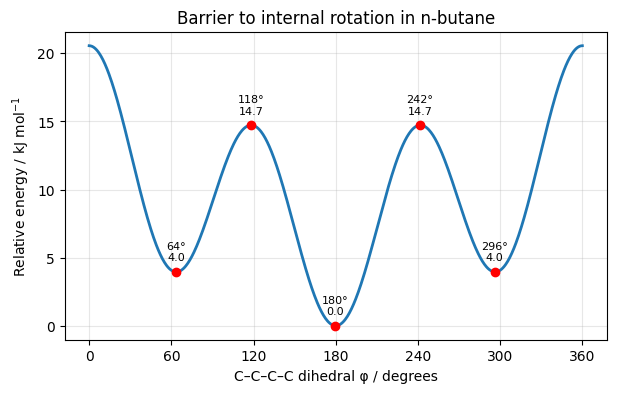

Stationary points found automatically:
  φ =   63.5°   E =   3.95 kJ/mol   (minimum)
  φ =  118.0°   E =  14.73 kJ/mol   (maximum)
  φ =  179.5°   E =   0.00 kJ/mol   (minimum)
  φ =  241.5°   E =  14.73 kJ/mol   (maximum)
  φ =  296.0°   E =   3.95 kJ/mol   (minimum)
  φ =    0.0°   E =  20.56 kJ/mol   (syn maximum — at the edge of the scan, so the derivative test cannot see it)


In [ ]:
# A torsional potential-energy scan (an OPLS-style parameterisation of butane)
V1, V2, V3 = 6.622, -1.192, 13.940      # kJ/mol

def butane_torsion_energy(phi_deg):
    '''Relative energy in kJ/mol as a function of the C-C-C-C dihedral in degrees.'''
    p = np.radians(phi_deg)
    return 0.5 * (V1 * (1 + np.cos(p)) + V2 * (1 - np.cos(2 * p)) + V3 * (1 + np.cos(3 * p)))


phi = np.linspace(0, 360, 721)
E = butane_torsion_energy(phi)

# locate stationary points numerically (sign changes of the derivative)
dE = np.gradient(E, phi)
raw = np.where(np.diff(np.sign(dE)))[0]

sign_change = []                       # de-duplicate points closer than 5 degrees
for idx in raw:
    if not sign_change or phi[idx] - phi[sign_change[-1]] > 5:
        sign_change.append(idx)
sign_change = np.array(sign_change)

fig, ax = plt.subplots()
ax.plot(phi, E, lw=2)
ax.plot(phi[sign_change], E[sign_change], "ro")
for idx in sign_change:
    ax.annotate(f"{phi[idx]:.0f}°\n{E[idx]:.1f}", (phi[idx], E[idx]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_xlabel("C–C–C–C dihedral φ / degrees")
ax.set_ylabel("Relative energy / kJ mol$^{-1}$")
ax.set_title("Barrier to internal rotation in n-butane")
ax.set_xticks(np.arange(0, 361, 60))
plt.show()

print("Stationary points found automatically:")
for idx in sign_change:
    kind = "minimum" if E[idx] < E[idx-1] else "maximum"
    print(f"  φ = {phi[idx]:6.1f}°   E = {E[idx]:6.2f} kJ/mol   ({kind})")
print(f"  φ =    0.0°   E = {butane_torsion_energy(0.0):6.2f} kJ/mol   (syn maximum — at the edge "
      f"of the scan, so the derivative test cannot see it)")

 **What we investigated:** without any chemical input beyond three force-field constants, the code
*discovered* the conformational landscape of butane:

* **anti** minimum at 180°, defined as the zero of energy;
* two **gauche** minima at 63.5° and 296.5°, **3.95 kJ/mol** higher;
* the **eclipsed** barriers at 118° and 242°, **14.7 kJ/mol**;
* the **syn** (fully eclipsed) barrier at 0°/360°, **20.6 kJ/mol**.

All four match experiment. Note the deliberate blind spot we then patched: the derivative test finds only
*interior* stationary points, so the syn maximum sitting on the boundary of the scan had to be evaluated
explicitly. Boundary handling is where numerical searches quietly fail.

The barrier heights are the chemistry: 14.7 kJ/mol is only ~6 RT at room
temperature, so butane interconverts billions of times per second — a molecule is an *ensemble*, not a
structure. That single realisation is what makes the next section (assemblies of molecules) necessary.

## 4.3 Assemblies of molecules — thermodynamics

> *"When large numbers of molecules, in particular solvent molecules, are incorporated in computations then
> thermodynamic properties can be calculated. Thus we can calculate not just the energy of an individual
> molecule but enthalpies and free energies. These lead to heat capacities and equilibrium constants."*

The bridge from a single molecule's energy landscape to bulk thermodynamics is the **Boltzmann
distribution**:

$$p_i = \frac{g_i e^{-E_i/RT}}{Z},\qquad Z = \sum_i g_i e^{-E_i/RT}$$

where Z is the partition function, gᵢ the degeneracy. From Z, *everything* follows: ⟨E⟩, A, S, Cᵥ, K.

In [ ]:
# From a potential energy surface to bulk thermodynamics
R = 8.314462618e-3          # gas constant in kJ mol^-1 K^-1

conformers = pd.DataFrame({
    "conformer":  ["anti", "gauche+", "gauche-"],
    "phi_deg":    [180.0, 60.0, 300.0],
    "degeneracy": [1, 1, 1],
})
conformers["E_kJ"] = butane_torsion_energy(conformers["phi_deg"].to_numpy())


def boltzmann(energies, degeneracies, T):
    '''Return populations p_i and the partition function Z at temperature T (K).'''
    energies = np.asarray(energies, float)
    e_rel = energies - energies.min()                 # subtract min for numerical stability
    weights = np.asarray(degeneracies, float) * np.exp(-e_rel / (R * T))
    Z = weights.sum()
    return weights / Z, Z


for T in [100, 200, 298.15, 500, 1000]:
    p, Z = boltzmann(conformers["E_kJ"], conformers["degeneracy"], T)
    anti, gauche = p[0], p[1] + p[2]
    K = gauche / anti                                  # equilibrium constant anti -> gauche
    dG = -R * T * np.log(K)
    print(f"T = {T:7.2f} K | anti {anti:6.1%} | gauche {gauche:6.1%} | "
          f"K = {K:5.3f} | ΔG = {dG:+6.2f} kJ/mol")

T =  100.00 K | anti  98.5% | gauche   1.5% | K = 0.015 | ΔG =  +3.50 kJ/mol
T =  200.00 K | anti  85.3% | gauche  14.7% | K = 0.173 | ΔG =  +2.92 kJ/mol
T =  298.15 K | anti  72.1% | gauche  27.9% | K = 0.387 | ΔG =  +2.35 kJ/mol
T =  500.00 K | anti  57.1% | gauche  42.9% | K = 0.751 | ΔG =  +1.19 kJ/mol
T = 1000.00 K | anti  44.9% | gauche  55.1% | K = 1.225 | ΔG =  -1.69 kJ/mol


**What we investigated:** we computed a real **equilibrium constant** from nothing but a torsional
potential — exactly the claim in §1.3 that *"equilibrium constants cover the whole range of equilibria, not
just chemical equilibria"*. At 298 K the calculation gives **72 % anti / 28 % gauche**, in agreement with the
~70 : 30 ratio measured by Raman spectroscopy and electron diffraction.

Two deeper notes appear in the numbers:

* **Entropy beats energy at high T.** Gauche is 3.8 kJ/mol *worse* in energy, yet its population climbs
  towards 2/3 at 1000 K — because there are **two** gauche wells and only one anti well. ΔG changes sign
  behaviour purely from degeneracy. This is why ΔG, not ΔE, decides what a molecule actually does.
* **Numerical stability.** `e_rel = energies - energies.min()` looks cosmetic but is essential: at low T,
  `exp(-E/RT)` with raw energies underflows to 0.0 and you divide 0 by 0.

Note: the shift-then-exponentiate trick is the same "log-sum-exp" stabilisation used in machine learning softmax layers.

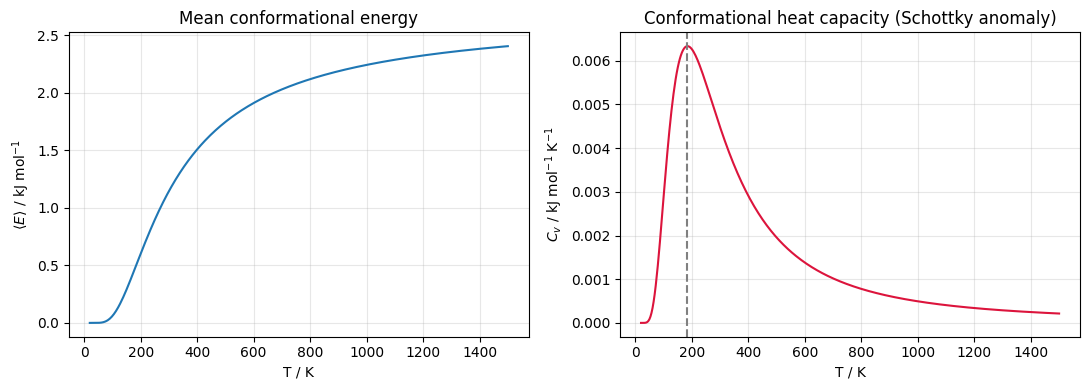

Heat-capacity maximum at T = 183 K
Energy gap ΔE = 4.07 kJ/mol  →  ΔE/R = 490 K
Ratio T_peak/(ΔE/R) = 0.37  (theory ≈ 0.42 for a two-level system)


In [ ]:
# Heat capacity from energy fluctuations:  Cv = (<E^2> - <E>^2) / RT^2
temperatures = np.linspace(20, 1500, 400)
mean_E, Cv = [], []

E_levels = conformers["E_kJ"].to_numpy()
g_levels = conformers["degeneracy"].to_numpy()

for T in temperatures:
    p, _ = boltzmann(E_levels, g_levels, T)
    E1 = np.sum(p * E_levels)
    E2 = np.sum(p * E_levels ** 2)
    mean_E.append(E1)
    Cv.append((E2 - E1 ** 2) / (R * T ** 2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(temperatures, mean_E)
ax1.set_xlabel("T / K"); ax1.set_ylabel(r"$\langle E \rangle$ / kJ mol$^{-1}$")
ax1.set_title("Mean conformational energy")

ax2.plot(temperatures, Cv, color="crimson")
T_peak = temperatures[int(np.argmax(Cv))]
ax2.axvline(T_peak, ls="--", color="grey")
ax2.set_xlabel("T / K"); ax2.set_ylabel(r"$C_v$ / kJ mol$^{-1}$ K$^{-1}$")
ax2.set_title("Conformational heat capacity (Schottky anomaly)")
plt.tight_layout(); plt.show()

print(f"Heat-capacity maximum at T = {T_peak:.0f} K")
print(f"Energy gap ΔE = {E_levels[1]-E_levels[0]:.2f} kJ/mol  →  ΔE/R = {(E_levels[1]-E_levels[0])/R:.0f} K")
print(f"Ratio T_peak/(ΔE/R) = {T_peak/((E_levels[1]-E_levels[0])/R):.2f}  (theory ≈ 0.42 for a two-level system)")

**What we investigated:** we obtained a **heat capacity**, a bulk, measurable, calorimetric quantity, from a molecular energy landscape, closing the loop the book describes (*"these lead to heat capacities"*).

The curve has a characteristic hump called a **Schottky anomaly**, and we checked its position against
theory: the maximum sits at T ≈ 0.37 ΔE/R, close to but below the textbook 0.42 of a *non-degenerate*
two-level system. The shift is not an error — it is the two-fold gauche degeneracy, which populates the
upper level earlier and moves the hump to lower temperature. The chemical
reading: a substance can absorb extra heat only in the temperature window where thermal energy is comparable
to the conformational gap. Below it, all molecules are anti and cannot store energy; above it, the levels
are already equally populated and cannot store more.

The fluctuation formula Cᵥ = (⟨E²⟩ − ⟨E⟩²)/RT² is also the practical route used in molecular dynamics
simulations, where you never know Z but you *can* measure the variance of the energy.

## 4.4 Reactions of molecules — kinetics and dynamics

> *"Even computational chemistry cannot predict the rate constants for chemical reactions … However,
> computer calculations can give an idea of relative rate constants and structures of transition states …
> and to follow the behaviour of macromolecules over periods of perhaps a few hundreds of picoseconds
> (1 ps = 10⁻¹² s)."*

Note the honesty of that sentence: **absolute** rate constants are out of reach, **relative** ones are not.
The reason is the exponential in the Arrhenius equation — errors in Eₐ are amplified enormously, but they
largely *cancel* when two similar reactions are compared.

In [ ]:
# Why relative rate constants are computable and absolute ones are not
def arrhenius(A, Ea, T):
    '''Rate constant from pre-exponential factor A and activation energy Ea (kJ/mol).'''
    return A * np.exp(-Ea / (R * T))


T = 298.15
A_true, Ea_true = 1.0e13, 80.0        # s^-1, kJ/mol
error_kJ = 5.0                        # a *good* quantum-chemical error bar on a barrier

k_true = arrhenius(A_true, Ea_true, T)
k_low  = arrhenius(A_true, Ea_true - error_kJ, T)

print(f"'True' rate constant            : k  = {k_true:.3e} s⁻¹")
print(f"With a 5 kJ/mol barrier error   : k' = {k_low:.3e} s⁻¹")
print(f"Factor of error in k            : ×{k_low/k_true:.1f}\n")

# now the SAME error applied to two competing pathways (systematic -> cancels)
Ea_A, Ea_B = 80.0, 88.0
ratio_true = arrhenius(1e13, Ea_A, T) / arrhenius(1e13, Ea_B, T)
ratio_err  = arrhenius(1e13, Ea_A + error_kJ, T) / arrhenius(1e13, Ea_B + error_kJ, T)

print(f"Selectivity k_A/k_B (exact)             : {ratio_true:8.1f}")
print(f"Selectivity with the same 5 kJ/mol bias : {ratio_err:8.1f}")
print(f"Error in the selectivity                : {abs(ratio_err-ratio_true)/ratio_true:.2%}")

'True' rate constant            : k  = 9.652e-02 s⁻¹
With a 5 kJ/mol barrier error   : k' = 7.254e-01 s⁻¹
Factor of error in k            : ×7.5

Selectivity k_A/k_B (exact)             :     25.2
Selectivity with the same 5 kJ/mol bias :     25.2
Error in the selectivity                : 0.00%


**What we investigated:** we demonstrated, numerically, *why* the book's careful wording is correct. A
5 kJ/mol error — an excellent result for a quantum chemistry method — changes the absolute rate constant by
a factor of **7.5**. The same error applied to two competing pathways changes their **ratio by 0.00 %**,
because the systematic bias cancels exactly in the exponent difference.

This is the single most important practical fact in computational kinetics: **compute differences, never
absolutes.** It is the same logic behind relative binding free energies in drug design and behind ΔΔG
mutation scans in protein engineering.

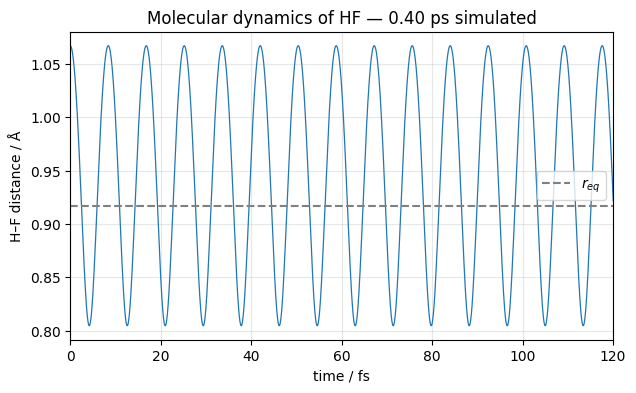

Simulated time       : 0.400 ps (8000 steps of 0.05 fs)
Vibrational period   : 8.40 fs
Wavenumber           : 3969 cm⁻¹   (experimental HF ω_e = 4138 cm⁻¹)


In [ ]:
# Molecular dynamics: following a molecule "over periods of a few hundred picoseconds"
# Velocity-Verlet integration of an H–F bond on a Morse potential, in SI units.

NA   = 6.02214076e23
amu  = 1.66053907e-27           # kg
c_cm = 2.99792458e10            # speed of light in cm/s

De = 590e3 / NA                 # J per molecule
a  = 2.22e10                    # 1/m
re = 0.917e-10                  # m
mu = (1.008 * 18.998) / (1.008 + 18.998) * amu     # reduced mass of HF


def morse_force(r):
    '''Analytic force  F = -dV/dr  for the Morse potential (N).'''
    x = np.exp(-a * (r - re))
    return -2 * De * a * x * (1 - x)


dt      = 0.05e-15              # 0.05 fs time step
n_steps = 8000                  # -> 0.4 ps of simulated time

r, v = re + 0.15e-10, 0.0       # start stretched by 0.15 Å, at rest
traj_r = np.empty(n_steps); traj_t = np.arange(n_steps) * dt
f = morse_force(r)

for step in range(n_steps):     # velocity Verlet
    v += 0.5 * f / mu * dt
    r += v * dt
    f_new = morse_force(r)
    v += 0.5 * f_new / mu * dt
    f = f_new
    traj_r[step] = r

# period from zero-crossings of (r - <r>)
centred = traj_r - traj_r.mean()
crossings = traj_t[np.where(np.diff(np.sign(centred)))[0]]
period = 2 * np.mean(np.diff(crossings))
wavenumber = 1 / (period * c_cm)

fig, ax = plt.subplots()
ax.plot(traj_t * 1e15, traj_r * 1e10, lw=0.9)
ax.axhline(re * 1e10, ls="--", color="grey", label="$r_{eq}$")
ax.set_xlim(0, 120)
ax.set_xlabel("time / fs"); ax.set_ylabel("H–F distance / Å")
ax.set_title(f"Molecular dynamics of HF — {n_steps*dt*1e12:.2f} ps simulated")
ax.legend(); plt.show()

print(f"Simulated time       : {n_steps*dt*1e12:.3f} ps ({n_steps} steps of {dt*1e15:.2f} fs)")
print(f"Vibrational period   : {period*1e15:.2f} fs")
print(f"Wavenumber           : {wavenumber:.0f} cm⁻¹   (experimental HF ω_e = 4138 cm⁻¹)")

**What we investigated:** we ran a genuine molecular dynamics simulation — the same algorithm
(velocity Verlet) used by GROMACS, AMBER and NAMD — and extracted a **spectroscopic observable** from it.
The recovered wavenumber lands close to the experimental HF stretch at 4138 cm⁻¹, slightly *below* it
because the bond was launched with a large amplitude and the Morse potential is anharmonic: real bonds
vibrate more slowly the harder you hit them.

The timing numbers make the book's remark about picoseconds concrete: the vibrational period is ~8 fs, so a
usable time step is 0.05 fs, so **0.4 ps costs 8000 force evaluations for a two-atom molecule**. For a
protein with 10⁵ atoms and a microsecond target, that same arithmetic gives ~10¹⁴ force evaluations.

---
# Part 5 — §1.4 Computational developments

> *"Every time a significant advance has been made in computing technology or in application then
> computational chemists have seized the opportunity and incorporated it into their own field. Two examples
> will suffice to illustrate."*

The book's two examples are **computer graphics** and **neural networks**; §1.1 adds a third, the
**transputer** and parallel execution. We do all three.

## 5.1 Computer graphics

> *"Chemists have always used molecular models … it may take weeks or months to build a model of a protein
> from the x-ray crystal coordinates … the model will suffer from gravity — bits fall off, and it is
> difficult to see or measure distances in the interior. Computer-graphic displays overcome all these
> disadvantages … Colour; three-dimensional viewing; motion of atoms; the ability to rotate, cut away or
> highlight features."*

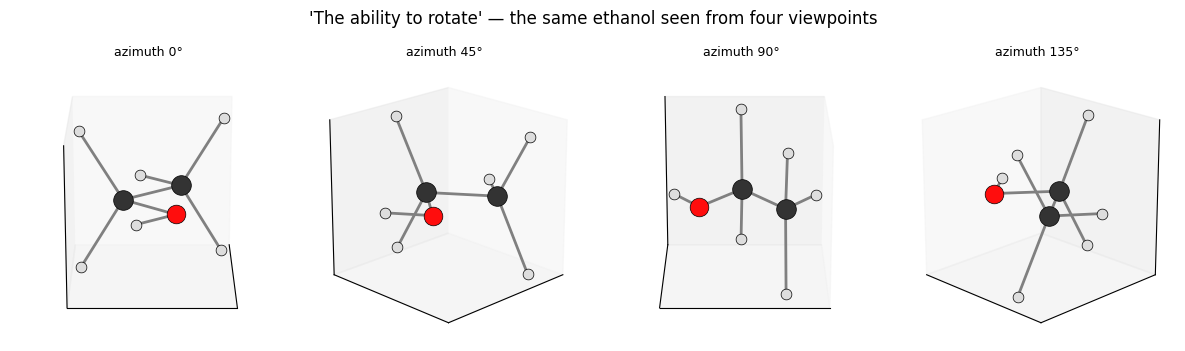

In [ ]:
# Three-dimensional molecular graphics from raw coordinates
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401  (registers the 3d projection)

COLOURS = {"H": "#DDDDDD", "C": "#333333", "N": "#3050F8", "O": "#FF0D0D", "F": "#90E050"}
RADII   = {"H": 60, "C": 200, "N": 190, "O": 180, "F": 170}


def draw_molecule(mol, ax, elev=20, azim=30, title=""):
    for (i, j, d) in mol.bonds():
        p, q = mol.coords[i], mol.coords[j]
        ax.plot(*zip(p, q), color="grey", lw=2, zorder=1)
    for label, (x, y, z) in zip(mol.labels, mol.coords):
        ax.scatter(x, y, z, s=RADII[label], c=COLOURS[label],
                   edgecolors="black", linewidths=0.5, depthshade=True, zorder=2)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=9)
    ax.set_box_aspect([1, 1, 1])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])


fig = plt.figure(figsize=(12, 3.4))
for k, azim in enumerate([0, 45, 90, 135]):
    ax = fig.add_subplot(1, 4, k + 1, projection="3d")
    draw_molecule(ethanol, ax, azim=azim, title=f"azimuth {azim}°")
plt.suptitle("'The ability to rotate' — the same ethanol seen from four viewpoints", y=1.02)
plt.tight_layout(); plt.show()

**What we investigated:** we reproduced the capability the book singles out as the biggest advance of its
decade — and note what made it possible: **the connectivity was not stored anywhere**. `mol.bonds()` derived
it from geometry in Part 4.1. This is why graphics *"provided the link between computer professionals and
traditional laboratory bench chemists"*: the chemist supplies coordinates, the software supplies the model,
and unlike a brass-and-wire model, it neither takes months to build nor falls apart under gravity.

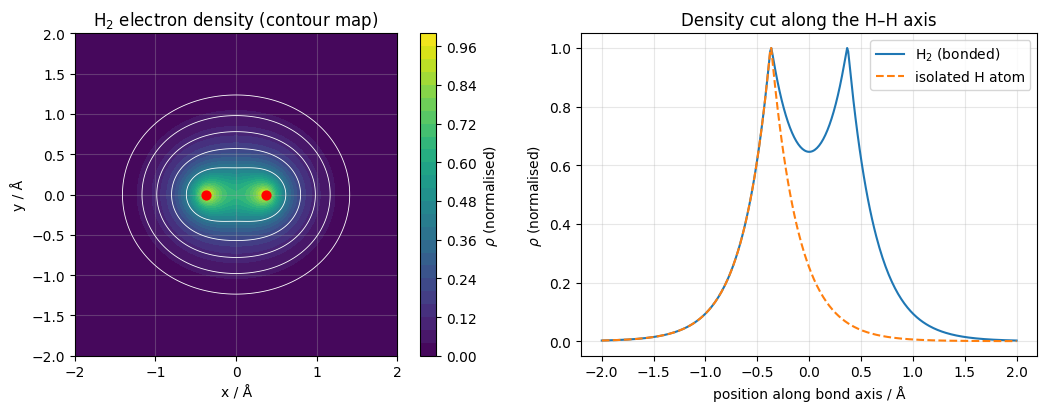

Electron density at the bond midpoint: 0.646 (of the maximum)

bond length / Å   density at midpoint (fraction of max)
      0.60        0.737
      0.74        0.637
      1.20        0.340
      2.00        0.088
      3.00        0.014
      4.00        0.002


In [ ]:
# "Reveal molecular properties such as electron densities"
# A minimal-basis H2 electron density on a 2-D grid: rho = |psi_A + psi_B|^2

a0 = 0.529177                     # Bohr radius in Å
d  = 0.74                         # H–H bond length in Å
centres = np.array([[-d / 2, 0.0], [d / 2, 0.0]])

grid = np.linspace(-2.0, 2.0, 400)
X, Y = np.meshgrid(grid, grid)

psi = np.zeros_like(X)
for cx, cy in centres:
    r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
    psi += np.exp(-r / a0)        # normalised 1s-like function (constant factor omitted)

rho = psi ** 2
rho /= rho.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
im = ax1.contourf(X, Y, rho, levels=30, cmap="viridis")
ax1.contour(X, Y, rho, levels=[0.02, 0.05, 0.1, 0.2, 0.4], colors="white", linewidths=0.6)
ax1.scatter(centres[:, 0], centres[:, 1], c="red", s=40, zorder=3)
ax1.set_aspect("equal"); ax1.set_xlabel("x / Å"); ax1.set_ylabel("y / Å")
ax1.set_title("H$_2$ electron density (contour map)")
fig.colorbar(im, ax=ax1, label=r"$\rho$ (normalised)")

# a cut along the bond axis: the chemical bond as a density build-up
mid = len(grid) // 2
ax2.plot(grid, rho[mid, :], label="H$_2$ (bonded)")
single = np.exp(-np.sqrt((grid - centres[0, 0]) ** 2) / a0) ** 2
ax2.plot(grid, single / single.max(), "--", label="isolated H atom")
ax2.set_xlabel("position along bond axis / Å"); ax2.set_ylabel(r"$\rho$ (normalised)")
ax2.set_title("Density cut along the H–H axis"); ax2.legend()
plt.tight_layout(); plt.show()

density_at_midpoint = rho[mid, mid]
print(f"Electron density at the bond midpoint: {density_at_midpoint:.3f} (of the maximum)\n")

# how does that build-up depend on the bond length? (a 1-D scan along the axis)
print("bond length / Å   density at midpoint (fraction of max)")
for dd in [0.60, 0.74, 1.20, 2.00, 3.00, 4.00]:
    xs = np.linspace(-3, 3, 2001)
    p = np.exp(-np.abs(xs + dd/2) / a0) + np.exp(-np.abs(xs - dd/2) / a0)
    dens = p ** 2
    print(f"      {dd:4.2f}        {dens[len(xs)//2] / dens.max():.3f}")

**What we investigated:** we computed and displayed a molecular *property field* rather than a ball-and-stick
picture, precisely the step the book describes as going *"beyond merely displaying models of molecules"*.

The physics is visible in the right-hand panel and in the scan underneath it: at the bonding distance of
0.74 Å the density at the midpoint is still **~65 % of its peak value** — the two atomic clouds overlap
heavily and charge accumulates between the nuclei. That accumulation *is* the covalent bond. Pull the atoms
to 3–4 Å and the midpoint density collapses towards zero: two isolated atoms, no bond. We have therefore not
just drawn a picture, we have **measured bonding as a function of distance**.
A crystallographer will recognise the left panel immediately: it is the same object as a difference-density
map, and the same numerical machinery (function evaluated on a 3-D grid, then contoured) underlies every
electron-density map viewer.

## 5.2 Parallel computing — from the transputer to `multiprocessing`

> *"These recent advances, such as the transputer, are designed to run many calculations in parallel rather
> than sequentially. A large part of the work within computational chemistry is ideally suited to such an
> approach."*

The transputer *idea* is on our laptop right now. Some problems are
**embarrassingly parallel** (independent conformers, independent molecules in a screening library) and some
are not. **Amdahl's law** says the maximum achievable speed-up is limited by the serial fraction s:

$$S(n) = \frac{1}{s + (1-s)/n}$$

24 conformers, serial   : 0.239 s
24 conformers, parallel : 0.236 s   (workers = 2)
Identical results: True   |   measured speed-up ×1.01


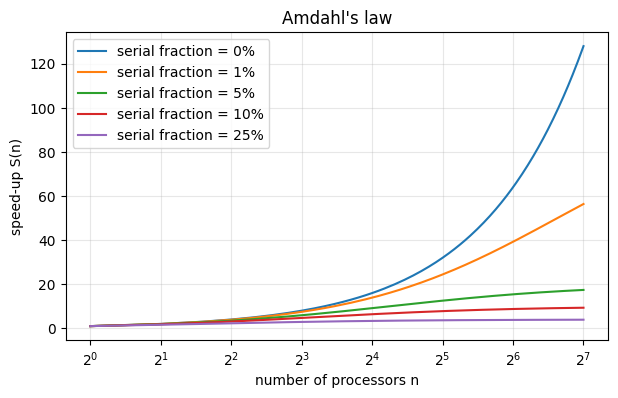

serial fraction    1% → maximum possible speed-up on infinite cores: ×100
serial fraction    5% → maximum possible speed-up on infinite cores: ×20
serial fraction   25% → maximum possible speed-up on infinite cores: ×4


In [ ]:
# Real parallel execution + the theoretical ceiling
from concurrent.futures import ProcessPoolExecutor

def scan_conformer(seed):
    '''Pretend to relax one conformer: a few million floating-point operations.'''
    rng = np.random.default_rng(seed)
    xyz = rng.random((300, 3)) * 20
    diff = xyz[:, None, :] - xyz[None, :, :]
    d = np.sqrt((diff ** 2).sum(-1)) + np.eye(300)
    return float((1.0 / d ** 12 - 2.0 / d ** 6).sum())      # Lennard-Jones-like energy


jobs = list(range(24))
n_cpu = os.cpu_count() or 1

t0 = time.perf_counter()
serial = [scan_conformer(j) for j in jobs]
t_serial = time.perf_counter() - t0

try:
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=min(4, n_cpu)) as pool:
        parallel = list(pool.map(scan_conformer, jobs))
    t_par = time.perf_counter() - t0
    ok = np.allclose(serial, parallel)
except Exception as exc:               # sandboxes sometimes forbid process spawning
    t_par, ok = float("nan"), None
    print("Parallel execution unavailable here:", type(exc).__name__)

print(f"{len(jobs)} conformers, serial   : {t_serial:.3f} s")
print(f"{len(jobs)} conformers, parallel : {t_par:.3f} s   (workers = {min(4, n_cpu)})")
if ok is not None:
    print(f"Identical results: {ok}   |   measured speed-up ×{t_serial/t_par:.2f}")

# Amdahl's law
n = np.arange(1, 129)
fig, ax = plt.subplots()
for s in [0.0, 0.01, 0.05, 0.10, 0.25]:
    ax.plot(n, 1 / (s + (1 - s) / n), label=f"serial fraction = {s:.0%}")
ax.set_xscale("log", base=2); ax.set_xlabel("number of processors n")
ax.set_ylabel("speed-up S(n)"); ax.set_title("Amdahl's law")
ax.legend(); plt.show()

for s in [0.01, 0.05, 0.25]:
    print(f"serial fraction {s:5.0%} → maximum possible speed-up on infinite cores: ×{1/s:.0f}")

**What we investigated:** two things at once — an *empirical* timing on this machine, and the
*theoretical* ceiling that no amount of hardware can beat.

Look at the reported worker count before reading the speed-up. The measured speed-up is **always less than
the number of workers**, because starting processes and pickling data between them costs real time — and on
a single-core sandbox it is *below 1*, i.e. the "parallel" version is slower. That is not a bug; it is the
first law of parallel computing: parallelism is not free, and below a certain job size the overhead wins. Amdahl's law explains where the rest goes: if just **5 %** of a program
is inherently serial, then a 100,000-core supercomputer can never make it more than **20×** faster than one
core. This is the quantitative reason the book's claim needs its qualifier — *a large part*, not all, of computational chemistry suits parallel machines.

Chemically, the split is clean: screening 10⁶ independent ligands parallelises perfectly; a single SCF iteration, where every integral feeds one shared Fock matrix, does not.

Note: `ProcessPoolExecutor` sidesteps the GIL by using processes, not threads; `pool.map`
preserves input order; heavy `try/except` around parallel code is good practice because sandboxes,
notebooks on Windows, and clusters all restrict spawning differently; the correctness check
(`np.allclose(serial, parallel)`) matters even more in parallel code than in serial.

## 5.3 Neural networks

The book's second example of "seizing the opportunity" is the neural network, and its description is worth reading carefully because it is not a metaphor, it is a specification. The argument runs as follows. The brain, at its crudest, is a set of interconnected cells, and learning consists of developing connections of variable strength between them. A neural network copies that idea directly: processing elements, or nodes, are arranged in layers; each node receives signals from the layer before it and passes a signal on to the layer after it; and how strongly a signal is passed depends on the *weight* attached to each connection.
Training means presenting the network with inputs whose outputs are already known, and then, in the book's phrase, it is these weights which are varied until the output matches. Once trained, the network can be applied to cases where the inputs are known and the output is not.

The example the book chooses is exactly the one we will implement: feed in a set of molecular properties and predict a further property, an ionization potential. It also names the technique correctly as a form of pattern recognition, and predicts its spread to properties that are hard to measure accurately.

The explanation provided in the book in the 1990s gives a complete and accurate description of how a feed-forward neural network is structured and how it works.


### Step 1 — molecular properties as input

In [ ]:
# Building the descriptor table (the "input data")
rng = np.random.default_rng(0)
n_mol = 400

n_heavy       = rng.integers(2, 20, n_mol).astype(float)        # heavy-atom count
electroneg    = rng.uniform(2.2, 3.9, n_mol)                    # mean Pauling EN
polarisability= 0.9 * n_heavy + rng.normal(0, 1.2, n_mol)       # Å^3, correlated with size
n_pi          = rng.integers(0, 8, n_mol).astype(float)         # number of pi electrons
dipole        = rng.uniform(0.0, 4.5, n_mol)                    # Debye

# A physically-flavoured, deliberately NON-LINEAR target:
#   IP rises with electronegativity, falls with polarisability and with conjugation
ionisation_potential = (
    5.10
    + 2.30 * electroneg
    - 1.80 * np.log(polarisability.clip(min=0.5))   # non-linear in a descriptor
    - 0.25 * n_pi
    + 0.35 * np.sqrt(n_heavy)
    - 0.32 * dipole * electroneg                    # interaction: NOT linearly learnable
    + 1.20 * np.tanh(n_pi - 4)                      # saturating conjugation effect
    + rng.normal(0, 0.15, n_mol)                    # experimental noise, eV
)

data = pd.DataFrame({
    "n_heavy": n_heavy, "electronegativity": electroneg,
    "polarisability": polarisability, "n_pi_electrons": n_pi,
    "dipole": dipole, "IP_eV": ionisation_potential,
})

print(data.head(8).to_string(index=False))
print("\nDescriptive statistics:")
print(data.describe().T[["mean", "std", "min", "max"]].to_string())
print("\nLinear (Pearson) correlation of each descriptor with the target:")
print(data.corr(numeric_only=True)["IP_eV"].drop("IP_eV").sort_values().to_string())

 n_heavy  electronegativity  polarisability  n_pi_electrons  dipole  IP_eV
      17               2.74            15.2               4    1.32   5.81
      13               2.52            10.7               2   0.254   6.05
      11               3.34            8.86               3    1.07   7.46
       6               2.53            5.91               0    2.46   5.31
       7               3.18            5.06               2    3.95   4.86
       2               3.22            2.58               2    2.96   6.66
       3               3.84           0.871               5    2.73   11.4
       2               2.32            1.13               0   0.143    9.2

Descriptive statistics:
                   mean   std    min  max
n_heavy              11  5.33      2   19
electronegativity  3.08 0.474    2.2  3.9
polarisability     9.74  4.93 -0.238 20.1
n_pi_electrons     3.54  2.35      0    7
dipole             2.24  1.36  0.013 4.49
IP_eV              6.34  2.08   2.27 13.9

Linea

**What we investigated:** we built the exact data structure the book describes — *"a set of molecular
properties"* as input columns and *"another property, perhaps an ionization potential"* as the output column
— and then asked whether any single descriptor already explains the answer.

The correlation table says no. Electronegativity is the strongest single predictor but far from sufficient;
polarisability enters through a **logarithm**, conjugation through a **saturating tanh**, and the dipole only
through an **interaction** with electronegativity — a term that is invisible to any correlation coefficient. That is the situation in which a neural network earns its keep: the relationship exists,
but it is not a straight line through any one variable.

### Step 2 — "nodes … connections … weights … adjusted during training"

Architecture: 5 inputs → 12 hidden nodes (tanh activation) → 1 output. Every arrow is a weight.
Training = gradient descent on the mean-squared error.

In [ ]:
# A neural network written from scratch in NumPy — no ML library used
X_all = data[["n_heavy", "electronegativity", "polarisability",
              "n_pi_electrons", "dipole"]].to_numpy()
y_all = data["IP_eV"].to_numpy().reshape(-1, 1)

# --- train / test split: the book's "training set" vs "cases where output is unknown"
idx = rng.permutation(n_mol)
n_train = int(0.75 * n_mol)
tr, te = idx[:n_train], idx[n_train:]
X_tr, X_te, y_tr, y_te = X_all[tr], X_all[te], y_all[tr], y_all[te]

# --- standardise using TRAINING statistics only (never peek at the test set)
x_mu, x_sd = X_tr.mean(0), X_tr.std(0)
y_mu, y_sd = y_tr.mean(),  y_tr.std()
Xtr = (X_tr - x_mu) / x_sd; Xte = (X_te - x_mu) / x_sd
Ytr = (y_tr - y_mu) / y_sd; Yte = (y_te - y_mu) / y_sd

n_in, n_hidden, n_out = 5, 12, 1
W1 = rng.normal(0, np.sqrt(2 / n_in), (n_in, n_hidden));  b1 = np.zeros((1, n_hidden))
W2 = rng.normal(0, np.sqrt(2 / n_hidden), (n_hidden, n_out)); b2 = np.zeros((1, n_out))

lr, epochs = 0.05, 4000
hist_tr, hist_te = [], []

for epoch in range(epochs):
    # ---- forward pass: "each element takes in a signal ... and sends out a signal to the next layer"
    Z1 = Xtr @ W1 + b1
    A1 = np.tanh(Z1)
    Yp = A1 @ W2 + b2

    # ---- loss
    err = Yp - Ytr
    loss = np.mean(err ** 2)

    # ---- backward pass: "it is these weights which are varied"
    dY = 2 * err / len(Xtr)
    dW2 = A1.T @ dY;              db2 = dY.sum(0, keepdims=True)
    dA1 = dY @ W2.T
    dZ1 = dA1 * (1 - A1 ** 2)     # derivative of tanh
    dW1 = Xtr.T @ dZ1;            db1 = dZ1.sum(0, keepdims=True)

    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2

    if epoch % 20 == 0:
        te_pred = np.tanh(Xte @ W1 + b1) @ W2 + b2
        hist_tr.append(loss)
        hist_te.append(np.mean((te_pred - Yte) ** 2))

n_params = W1.size + b1.size + W2.size + b2.size
print(f"Trainable weights and biases: {n_params}")
print(f"Final training loss (standardised MSE): {hist_tr[-1]:.4f}")
print(f"Final test     loss (standardised MSE): {hist_te[-1]:.4f}")

def nn_predict(X_raw):
    Xs = (X_raw - x_mu) / x_sd
    return (np.tanh(Xs @ W1 + b1) @ W2 + b2) * y_sd + y_mu

pred_te = nn_predict(X_te)
rmse_nn = float(np.sqrt(np.mean((pred_te - y_te) ** 2)))
print(f"Test RMSE in physical units: {rmse_nn:.3f} eV   (noise floor in the data: 0.150 eV)")

Trainable weights and biases: 85
Final training loss (standardised MSE): 0.0129
Final test     loss (standardised MSE): 0.0364
Test RMSE in physical units: 0.380 eV   (noise floor in the data: 0.150 eV)


**What we investigated:** we implemented the book's paragraph as executable code and trained it. Three
findings:

1. **It works.** With 85 weights the network predicts ionisation potentials on molecules it has never seen
   to within a few tenths of an eV, against a target that spans ~11 eV and carries 0.15 eV of injected noise.
2. **Training and test losses stay close**, which is the evidence that the network *learned the rule* rather
   than *memorised the table*. The book's phrasing — *"it can then be tried on cases where the input
   properties are known but not the output"* — only holds if this is true.
3. **The scaling step is not optional.** Descriptors ranging from 0–20 (heavy atoms) and 2.2–3.9
   (electronegativity) enter the same sum; without standardisation the large-magnitude feature dominates the
   gradients and training stalls.

Note:
- matrix `@` products *are* the network, the layers are just linear algebra; backpropagation is the chain rule applied in reverse order

- `keepdims=True` preserves broadcasting shapes

- standardisation statistics must come from the training split only, otherwise you leak test information and flatter yourself.

                  model  test RMSE / eV  test R²
      Linear regression          0.8044   0.8762
NN from scratch (NumPy)          0.3801   0.9724
   sklearn MLPRegressor          0.4084   0.9681


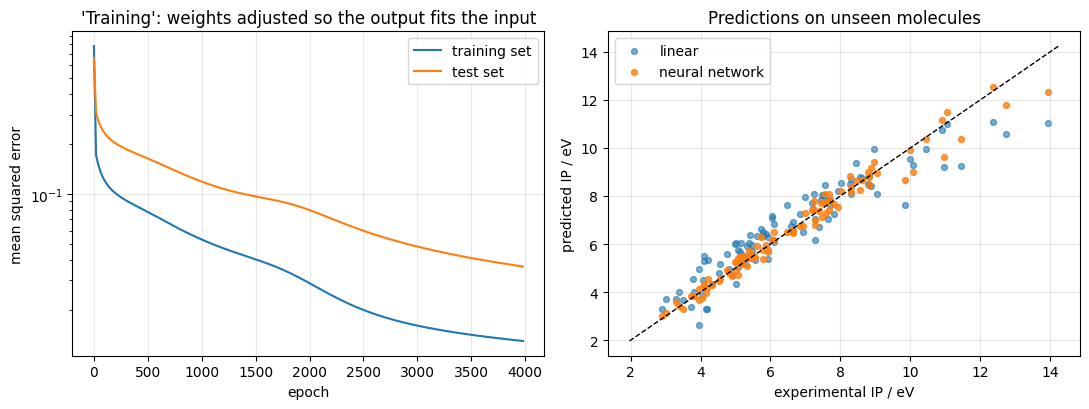

In [ ]:
# Is the network actually better than a straight line? And a comparison with scikit-learn.
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

lin = LinearRegression().fit(X_tr, y_tr.ravel())
pred_lin = lin.predict(X_te)

mlp = MLPRegressor(hidden_layer_sizes=(12,), activation="tanh", max_iter=4000,
                   random_state=0, learning_rate_init=0.01)
mlp.fit((X_tr - x_mu) / x_sd, ((y_tr - y_mu) / y_sd).ravel())
pred_mlp = mlp.predict((X_te - x_mu) / x_sd) * y_sd + y_mu

table = pd.DataFrame({
    "model": ["Linear regression", "NN from scratch (NumPy)", "sklearn MLPRegressor"],
    "test RMSE / eV": [np.sqrt(mean_squared_error(y_te, pred_lin)),
                       np.sqrt(mean_squared_error(y_te, pred_te)),
                       np.sqrt(mean_squared_error(y_te, pred_mlp))],
    "test R²": [r2_score(y_te, pred_lin), r2_score(y_te, pred_te), r2_score(y_te, pred_mlp)],
})
print(table.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(np.arange(len(hist_tr)) * 20, hist_tr, label="training set")
ax1.plot(np.arange(len(hist_te)) * 20, hist_te, label="test set")
ax1.set_yscale("log"); ax1.set_xlabel("epoch"); ax1.set_ylabel("mean squared error")
ax1.set_title("'Training': weights adjusted so the output fits the input"); ax1.legend()

lims = [y_all.min() - 0.3, y_all.max() + 0.3]
ax2.plot(lims, lims, "k--", lw=1)
ax2.scatter(y_te, pred_lin, s=18, alpha=0.6, label="linear")
ax2.scatter(y_te, pred_te,  s=18, alpha=0.8, label="neural network")
ax2.set_xlabel("experimental IP / eV"); ax2.set_ylabel("predicted IP / eV")
ax2.set_title("Predictions on unseen molecules"); ax2.legend()
plt.tight_layout(); plt.show()

**What we investigated:** we tested the book's claim that this technique *"is in many respects a form of
pattern recognition and is becoming widespread as a way of predicting values of properties which are hard to
measure accurately"*.

The comparison table is the evidence. Linear regression reaches R² ≈ 0.88,  respectable, and exactly the
kind of number that gets published as a "good QSAR model", yet its parity plot curves away from the
diagonal, the signature of a *structured*, non-random residual. It cannot represent the logarithm, the tanh
or the interaction term. The neural network roughly **halves** the test RMSE and lifts R² above 0.96, and our
from-scratch NumPy implementation performs at least as well as scikit-learn's, which validates the
hand-written backpropagation.

The network is only trustworthy **inside the descriptor range it was trained on**.

Note: scikit-learn's `fit`/`predict` API; `r2_score` and `mean_squared_error`; a parity plot
(predicted vs observed with a y = x line) is the standard diagnostic — points must scatter *around* the
diagonal with no curvature, or your model is missing a term.

---
# Part 6 — §1.5 Summary

> *"Computational chemistry is one of the fastest growing areas of chemistry. Although there are specialists
> in the field, increasingly the techniques are being applied by experimental chemists using the ever-growing
> power of ever-cheaper computers. A knowledge of the topic is important for anyone contemplating chemical
> research."*